In [28]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import seaborn as sns
from matplotlib import pyplot as plt


In [29]:
pd.set_option('display.max_columns', 350)
pd.set_option('display.max_rows', 350)

In [30]:
runs_folders = [
    # "/workspace-SR006.nfs2/bulatov/rmt/test-time/compressing-associations/runs-rebuttal-default",
    "/home/bulatov/rmt/test-time/compressing-associations/runs-rebuttal-default",
]

base_dir = Path("/workspace-SR006.nfs2/bulatov/rmt/test-time/compressing-associations")


In [31]:
all_runs = []
for runs_folder in runs_folders:
    runs_path = Path(runs_folder)
    target_runs = list(runs_path.glob('**/run_*'))
    
    for run_path in target_runs:
        if not run_path.is_dir():
            continue
        # skip checkpoint subdirs
        if 'checkpoint' in str(run_path):
            continue
            
        run_stats = {}
        run_stats['run_path'] = str(run_path)
        run_stats['runs_folder'] = runs_path.name
        run_stats['run_name'] = run_path.parent.name
        run_stats['task_name'] = run_path.parent.parent.name
        run_stats['run_id'] = int(run_path.name.split('_')[1])
        
        config_path = run_path / 'config.json'
        if config_path.exists():
            cli_args = json.load(open(config_path))['cli_args']
            run_stats.update(cli_args)
        
        results_path = run_path / 'all_results.json'
        if results_path.exists():
            results = json.load(open(results_path))
            run_stats.update(results)
        else:
            run_stats['eval_exact_match'] = np.nan
            run_stats['eval_token_accuracy'] = np.nan
        all_runs.append(run_stats)
df = pd.DataFrame(all_runs)
print(f"Total runs: {len(df)}")
print(f"Columns: {list(df.columns)}")
# df

Total runs: 731
Columns: ['run_path', 'runs_folder', 'run_name', 'task_name', 'run_id', 'exp_path', 'per_device_batch_size', 'data_path', 'tokenizer_path', 'gradient_accumulation_steps', 'total_batch_size', 'metric_for_best_model', 'warmup_steps', 'max_steps', 'logging_steps', 'eval_steps', 'weight_decay', 'learning_rate', 'adam_beta1', 'adam_beta2', 'adam_epsilon', 'lr_scheduler_type', 'early_stopping_patience', 'seed', 'base_model', 'pretrained_model', 'n_layer', 'n_head', 'n_embd', 'state_size', 'conv_kernel', 'no_conv', 'max_position_embeddings', 'max_input_length', 'attn_implementation', 'n_pairs', 'n_keys', 'n_values', 'overwrite_output_dir', 'do_eval_only', 'eval_exact_match', 'eval_token_accuracy', 'epoch', 'eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'num_input_tokens_seen', 'patience']


In [32]:
import re

def parse_run_name(run_name):
    info = {}
    
    m = re.match(r'^(.+?)_L(\d+)H(\d+)D(\d+)(.*)', run_name)
    if not m:
        return info
    
    info['model'] = m.group(1)
    info['L'] = int(m.group(2))
    info['H'] = int(m.group(3))
    info['D'] = int(m.group(4))
    rest = m.group(5)
    
    mem_match = re.search(r'_mem(\d+)', rest)
    if mem_match:
        info['mem'] = int(mem_match.group(1))
    
    seg_match = re.search(r'-(\d+x\d+)', rest)
    if seg_match:
        info['segment'] = seg_match.group(1)
    
    return info

parsed = df['run_name'].apply(parse_run_name).apply(pd.Series)
df = pd.concat([df, parsed], axis=1)

In [33]:
def calc_recurrent_state_size(row, include_conv=False,
                               mamba_expand=2, mamba2_head_dim=64, gdn_expand_v=2.0):
    """
    Calculate the total recurrent state size (number of scalar elements)
    for mamba / mamba2 / gated_delta_net models.

    Parameters taken directly from a results DataFrame row:
        base_model, n_layer, n_embd, state_size, conv_kernel, n_head (optional, default 1)

    Args:
        row          : pd.Series (a single DataFrame row)
        include_conv : also count the short-conv buffer (conv_kernel-1 elements per channel)
        mamba_expand : expand factor (default 2, matches FLA MambaConfig default)
        mamba2_head_dim : head_dim used by Mamba2 (default 64, matches FLA Mamba2Config default)
        gdn_expand_v : expand_v for GDN value projection (default 2.0, matches GatedDeltaNetConfig default)
    """
    base_model  = row['base_model']
    n_layer     = int(row['n_layer'])
    n_embd      = int(row['n_embd'])
    state_size  = int(row['state_size'])
    conv_kernel = int(row['conv_kernel'])
    n_head      = int(row.get('n_head', 1))

    if base_model in ('mamba', 'mamba2'):
        # d_inner = expand * n_embd  (both architectures default expand=2)
        # SSM state per layer: d_inner × state_size
        # (Mamba2: num_heads = d_inner/head_dim, state shape [H, state_size, head_dim]
        #  → same total: d_inner × state_size)
        d_inner   = mamba_expand * n_embd
        ssm_state = n_layer * d_inner * state_size
        if include_conv:
            # conv buffer per layer: d_inner × (conv_kernel − 1)
            return ssm_state + n_layer * d_inner * (conv_kernel - 1)
        return ssm_state

    elif base_model == 'gated_delta_net':
        # build_fla_config sets: head_dim = state_size // n_head
        # GDN layer:  head_k_dim = head_dim,  head_v_dim = head_dim × expand_v
        # Recurrent state per layer: [num_heads, head_k_dim, head_v_dim]
        head_dim   = state_size // n_head
        head_v_dim = int(head_dim * gdn_expand_v)
        recurrent  = n_layer * n_head * head_dim * head_v_dim
        if include_conv:
            # v_conv1d on value_dim = n_head × head_v_dim channels, depth (conv_size − 1)
            value_dim = n_head * head_v_dim
            return recurrent + n_layer * value_dim * (conv_kernel - 1)
        return recurrent

    else:
        raise ValueError(f"Unsupported base_model: {base_model!r}")

In [34]:
df.loc[df.run_name.apply(lambda x: 'noconv' in x), "conv_kernel"] = 0

In [35]:
# df.conv_kernel = df.conv_kernel.fillna(0)
# df
df['recurrent_state_size'] = df.apply(calc_recurrent_state_size, axis=1)
# or with conv buffer included:
df['recurrent_state_size_with_conv'] = df.apply(
    lambda row: calc_recurrent_state_size(row, include_conv=True), axis=1
)

In [36]:
df.shape

(731, 51)

In [37]:
# df['eval_exact_match'] = df['eval_exact_match'].fillna(df['eval_exact_match_base'])
df = df.dropna(subset=['eval_exact_match'])

# df.mem = df.mem.fillna(0).astype(int)
# df.segment = df.segment.fillna('1x' + df.

df['modification'] = ''
df.loc[df.max_steps == 200000, 'modification'] += ' 2x steps'

df['n_pairs'] = df.task_name.apply(lambda x: int(x[1:].split('-')[0]))

In [42]:
group_cols = [
    'task_name',              # or ['n_pairs', 'n_keys', 'n_values'] if you prefer explicit task identity
    'base_model',
    'n_layer',
    'n_embd',
    'state_size',
    'conv_kernel',
    # 'learning_rate',
    'recurrent_state_size',
    'recurrent_state_size_with_conv',
    # 'per_device_batch_size',
    # 'adam_beta2',
    # 'max_steps',              # better than grouping by the derived 'modification' label
]

In [47]:
import re

def extract_n_pairs(task_name):
    """Extracts the n_pairs integer value from the task_name string."""
    match = re.search(r'^N(\d+)-', task_name)
    if match:
        return int(match.group(1))
    return float('inf')  # To sort unmatchable names last

grouped = df.groupby(group_cols, dropna=False).agg(
    avg_em=('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
    std_em=('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
    all_ems=('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
    n_runs=('eval_exact_match', 'count'),
)

# Add index as columns for sorting
grouped_reset = grouped.reset_index()
if 'task_name' in grouped_reset.columns:
    grouped_reset['n_pairs'] = grouped_reset['task_name'].apply(extract_n_pairs)
    grouped_reset = grouped_reset.sort_values('n_pairs')
    grouped_sorted = grouped_reset.drop('n_pairs', axis=1).set_index(group_cols)
else:
    grouped_sorted = grouped
grouped_sorted

avg_em  \
task_name       base_model      n_layer n_embd state_size conv_kernel recurrent_state_size recurrent_state_size_with_conv           
N2-K2V2-V62_1M  gated_delta_net 4       128    16         0.0         512                  384                              99.07   
N4-K2V2-V62_1M  gated_delta_net 4       128    16         0.0         512                  384                              45.61   
N8-K2V2-V62_1M  gated_delta_net 1       64     16         4.0         512                  608                              59.80   
                                                          2.0         512                  544                              12.80   
                                               4          4.0         32                   56                                0.93   
                                                          2.0         32                   40                                1.11   
                                               32         2.0         2048                 2112                             13.27   
                mamba           1       128    4          2.0         1024                 1280                             12.39   
                                        64     32         4.0         4096                 4480                             94.98   
                                                          2.0         4096                 4224                             13.07   
                                               16         4.0         2048                 2432                             95.89   
                                                          2.0         2048                 2176                             13.55   
                                               4          4.0         512                  896                              81.89   
                                                          2.0         512                  640                              11.49   
                gated_delta_net 4       256    32         4.0         8192                 8960                             98.03   
                                                          2.0         8192                 8448                             92.15   
                                               16         4.0         2048                 2432                             97.89   
                                                          2.0         2048                 2176                             35.87   
                                               4          4.0         128                  224                              13.55   
                                                          2.0         128                  160                               6.11   
                                        128    32         4.0         8192                 8960                             99.91   
                                                          2.0         8192                 8448                             95.93   
                                               16         4.0         2048                 2432                             99.27   
                                                          2.0         2048                 2176                             68.71   
                                                          0.0         512                  384                               9.55   
                                               4          4.0         128                  224                               9.01   
                                                          2.0         128                  160                               5.85   
                                        64     32         4.0         8192                 8960                             99.95   
                                                          2.0         8192                 8448                             41.24   


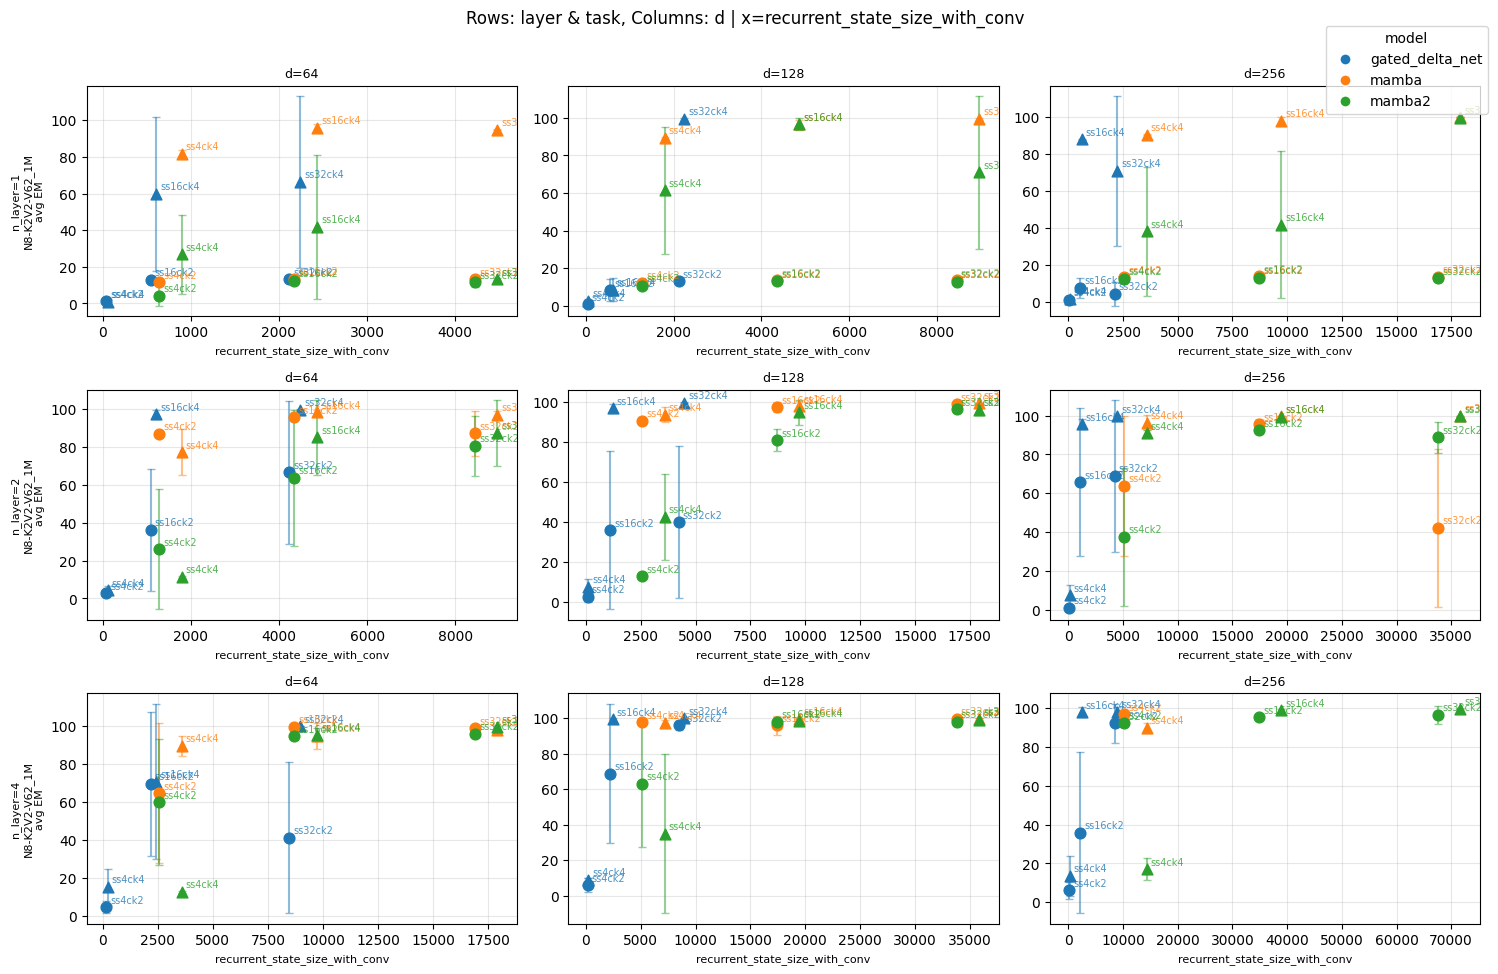

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# X_COL = 'recurrent_state_size'   # or 'recurrent_state_size_with_conv'
X_COL = 'recurrent_state_size_with_conv'

g = grouped.reset_index()
g = g[g.task_name == "N8-K2V2-V62_1M"]

# Instead of filtering for n_layer==1, we keep all and plot each n_layer in a separate row
layer_order    = sorted(g['n_layer'].unique())
nembd_order    = sorted(g['n_embd'].unique())
task_order     = sorted(g['task_name'].unique())
model_order    = sorted(g['base_model'].unique())

palette = dict(zip(model_order, plt.cm.tab10.colors))

# Marker mapping for conv_kernel
ck_marker_map = {2: 'o', 4: '^'}

n_rows = len(layer_order) * len(task_order)
n_cols = len(nembd_order)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 3.2 * n_rows),
                         sharey=False, sharex=False)

axes = np.array(axes).reshape(n_rows, n_cols)

for li, n_layer in enumerate(layer_order):
    for ti, task in enumerate(task_order):
        row_index = li * len(task_order) + ti
        for ci, nembd in enumerate(nembd_order):
            ax = axes[row_index, ci]
            sub = g[(g['n_layer'] == n_layer) &
                    (g['task_name'] == task) &
                    (g['n_embd'] == nembd)]
            for model, grp in sub.groupby('base_model'):
                c = palette[model]
                # Draw each point individually with marker depending on conv_kernel
                for _, row in grp.iterrows():
                    marker = ck_marker_map.get(int(row['conv_kernel']), 'o')
                    ax.scatter(row[X_COL], row['avg_em'],
                               color=c, label=model, zorder=3, s=60, marker=marker)
                    # --- label each dot ---
                    label = f"ss{int(row['state_size'])}ck{int(row['conv_kernel'])}"
                    ax.annotate(label,
                                xy=(row[X_COL], row['avg_em']),
                                xytext=(3, 3), textcoords='offset points',
                                fontsize=7, color=c, alpha=0.8,
                                clip_on=True)
                # error bars = std
                ax.errorbar(grp[X_COL], grp['avg_em'],
                            yerr=grp['std_em'],
                            fmt='none', color=c, alpha=0.5, capsize=3)
            if ci == 0:
                ax.set_ylabel(f'n_layer={n_layer}\n{task}\navg EM', fontsize=8)
            else:
                ax.set_ylabel('')
            ax.set_xlabel(X_COL, fontsize=8)
            ax.set_title(f'd={nembd}', fontsize=9)
            ax.grid(True, alpha=0.3)

# single legend (model colors)
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=palette[m], markersize=8, label=m)
           for m in model_order]
fig.legend(handles=handles, title='model', loc='upper right',
           bbox_to_anchor=(1.0, 1.0))

# # marker-type legend
# marker_handles = [
#     plt.Line2D([0], [0], marker='o', color='k', linestyle='None', markersize=8, label='ck=2'),
#     plt.Line2D([0], [0], marker='^', color='k', linestyle='None', markersize=8, label='ck=4')
# ]
# fig.legend(handles=marker_handles, title='conv_kernel', loc='upper right',
#            bbox_to_anchor=(1.0, 0.87))

fig.suptitle(f'Rows: layer & task, Columns: d | x={X_COL}', y=1.01)
fig.tight_layout()
fig.savefig('images/compressing_associations_plot.png', dpi=300, bbox_inches='tight')

plt.show()

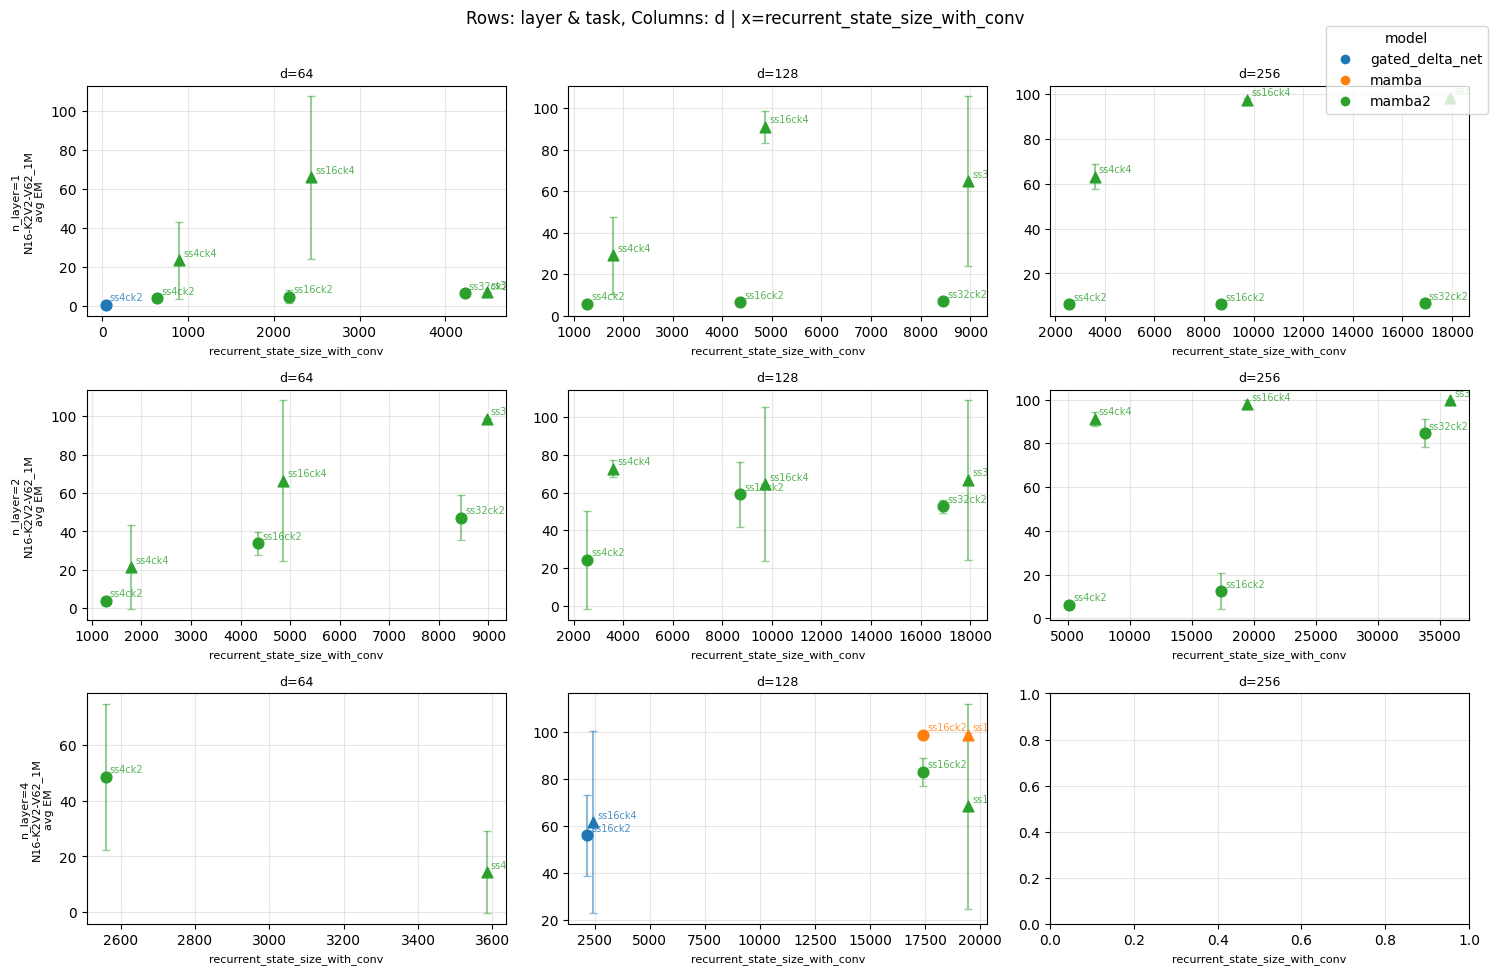

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# X_COL = 'recurrent_state_size'   # or 'recurrent_state_size_with_conv'
X_COL = 'recurrent_state_size_with_conv'

g = grouped.reset_index()
g = g[g.task_name == "N16-K2V2-V62_1M"]

# Instead of filtering for n_layer==1, we keep all and plot each n_layer in a separate row
layer_order    = sorted(g['n_layer'].unique())
nembd_order    = sorted(g['n_embd'].unique())
task_order     = sorted(g['task_name'].unique())
model_order    = sorted(g['base_model'].unique())

palette = dict(zip(model_order, plt.cm.tab10.colors))

# Marker mapping for conv_kernel
ck_marker_map = {2: 'o', 4: '^'}

n_rows = len(layer_order) * len(task_order)
n_cols = len(nembd_order)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 3.2 * n_rows),
                         sharey=False, sharex=False)

axes = np.array(axes).reshape(n_rows, n_cols)

for li, n_layer in enumerate(layer_order):
    for ti, task in enumerate(task_order):
        row_index = li * len(task_order) + ti
        for ci, nembd in enumerate(nembd_order):
            ax = axes[row_index, ci]
            sub = g[(g['n_layer'] == n_layer) &
                    (g['task_name'] == task) &
                    (g['n_embd'] == nembd)]
            for model, grp in sub.groupby('base_model'):
                c = palette[model]
                # Draw each point individually with marker depending on conv_kernel
                for _, row in grp.iterrows():
                    marker = ck_marker_map.get(int(row['conv_kernel']), 'o')
                    ax.scatter(row[X_COL], row['avg_em'],
                               color=c, label=model, zorder=3, s=60, marker=marker)
                    # --- label each dot ---
                    label = f"ss{int(row['state_size'])}ck{int(row['conv_kernel'])}"
                    ax.annotate(label,
                                xy=(row[X_COL], row['avg_em']),
                                xytext=(3, 3), textcoords='offset points',
                                fontsize=7, color=c, alpha=0.8,
                                clip_on=True)
                # error bars = std
                ax.errorbar(grp[X_COL], grp['avg_em'],
                            yerr=grp['std_em'],
                            fmt='none', color=c, alpha=0.5, capsize=3)
            if ci == 0:
                ax.set_ylabel(f'n_layer={n_layer}\n{task}\navg EM', fontsize=8)
            else:
                ax.set_ylabel('')
            ax.set_xlabel(X_COL, fontsize=8)
            ax.set_title(f'd={nembd}', fontsize=9)
            ax.grid(True, alpha=0.3)

# single legend (model colors)
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=palette[m], markersize=8, label=m)
           for m in model_order]
fig.legend(handles=handles, title='model', loc='upper right',
           bbox_to_anchor=(1.0, 1.0))

# # marker-type legend
# marker_handles = [
#     plt.Line2D([0], [0], marker='o', color='k', linestyle='None', markersize=8, label='ck=2'),
#     plt.Line2D([0], [0], marker='^', color='k', linestyle='None', markersize=8, label='ck=4')
# ]
# fig.legend(handles=marker_handles, title='conv_kernel', loc='upper right',
#            bbox_to_anchor=(1.0, 0.87))

fig.suptitle(f'Rows: layer & task, Columns: d | x={X_COL}', y=1.01)
fig.tight_layout()
fig.savefig('images/compressing_associations_plot-n16.png', dpi=300, bbox_inches='tight')

plt.show()